In [64]:
import datetime as dt
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns
from collections import namedtuple
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

### Hedging with Real SPX Option Data

The following cell will load the data, and cleans it up, dropping all columns that are unusefull.

In [117]:
import pandas as pd
import numpy as np

# -----------------------------
# Load data
# -----------------------------
df_raw = pd.read_csv("option20230201_20230228.csv")
rows_raw = len(df_raw)
print("Rows raw:", rows_raw)

# -----------------------------
# Convert dates (do this early)
# -----------------------------
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw["exdate"] = pd.to_datetime(df_raw["exdate"])

# -----------------------------
# Keep calls only
# -----------------------------
df_raw = df_raw[df_raw["cp_flag"] == "C"].copy()
rows_calls_only = len(df_raw)

# -----------------------------
# Rescale strikes if needed (SPX / OptionMetrics often stores strike*1000)
# -----------------------------
df_raw["strike_price"] = df_raw["strike_price"] / 1000.0

# -----------------------------
# Construct option midquote (call it C_t to avoid confusion with underlying)
# -----------------------------
df_raw["V_t"] = (df_raw["best_bid"] + df_raw["best_offer"]) / 2.0

# Optional: remove broken quotes
df_raw = df_raw[(df_raw["best_bid"] > 0) & (df_raw["best_offer"] > 0)]
df_raw = df_raw[df_raw["best_offer"] >= df_raw["best_bid"]]
df_raw = df_raw[df_raw["V_t"] > 0]

# -----------------------------
# Remove missing / invalid implied vol
# -----------------------------
df_raw = df_raw[df_raw["impl_volatility"].notna()]
df_raw = df_raw[df_raw["impl_volatility"] > 0]
rows_after_iv_filter = len(df_raw)

# -----------------------------
# Compute dte and tau
# -----------------------------
df_raw["dte"] = (df_raw["exdate"] - df_raw["date"]).dt.days
df_raw = df_raw[df_raw["dte"] > 0]  # drop expiry-day and negative
df_raw["tau"] = df_raw["dte"] / 365.0

# -----------------------------
# Remove duplicates correctly: one row per optionid-date
# -----------------------------
df_raw = df_raw.sort_values(["optionid", "date"])
df_raw = df_raw.drop_duplicates(subset=["optionid", "date"], keep="last")

# -----------------------------
# Keep useful columns
# -----------------------------
final_columns = [
    "optionid", "date", "exdate", "dte", "tau",
    "strike_price", "C_t",
    "V_t", "impl_volatility", "delta"
]

# Keep only columns that actually exist (safer)
final_columns = [c for c in final_columns if c in df_raw.columns]
df = df_raw[final_columns].copy()

# -----------------------------
# Required reporting
# -----------------------------
n_unique_dates = df["date"].nunique()
n_unique_expiries = df["exdate"].nunique()

missing_rate_Ct = df["C_t"].isna().mean() if "C_t" in df.columns else np.nan
missing_rate_Vt = df["V_t"].isna().mean() if "V_t" in df.columns else np.nan
missing_rate_iv = df["impl_volatility"].isna().mean()
missing_rate_delta = df["delta"].isna().mean() if "delta" in df.columns else np.nan

print("=== STEP 1 REPORT ===")
print("Rows raw:", rows_raw)
print("Rows after keeping calls:", rows_calls_only)
print("Rows after IV filter:", rows_after_iv_filter)
print("Unique trading dates:", n_unique_dates)
print("Unique expiries:", n_unique_expiries)
print("Missing rate C_t (option mid):", missing_rate_Ct)
print("Missing rate V_t (underlying):", missing_rate_Vt)
print("Missing rate impl vol:", missing_rate_iv)
print("Missing rate delta:", missing_rate_delta)
print("Final columns:", df.columns.tolist())

Rows raw: 175301
=== STEP 1 REPORT ===
Rows raw: 175301
Rows after keeping calls: 175301
Rows after IV filter: 145834
Unique trading dates: 19
Unique expiries: 67
Missing rate C_t (option mid): nan
Missing rate V_t (underlying): 0.0
Missing rate impl vol: 0.0
Missing rate delta: 0.0
Final columns: ['optionid', 'date', 'exdate', 'dte', 'tau', 'strike_price', 'V_t', 'impl_volatility', 'delta']


In [118]:
print("Unique dates:", df["date"].nunique())
print("Max obs per optionid:", df.groupby("optionid").size().max())

df = df.sort_values(["optionid", "date"]).copy()

df = df.drop_duplicates(subset=["optionid", "date"], keep="last").copy()

df["V_t_plus_1"] = df.groupby("optionid")["V_t"].shift(-1)
df["dV_t"] = df["V_t_plus_1"] - df["V_t"]

df = df[df["dV_t"].notna()].copy()

print("=== STEP 2 REPORT ===")
print("\nV_t summary:")
print(df["V_t"].describe())

print("\nΔV_t summary:")
print(df["dV_t"].describe())

print("Min date:", df["date"].min())
print("Max date:", df["date"].max())
print("Unique dates:", df["date"].nunique())

Unique dates: 19
Max obs per optionid: 19
=== STEP 2 REPORT ===

V_t summary:
count    134103.000000
mean        454.893245
std         585.272356
min           0.075000
25%          55.300000
50%         233.200000
75%         633.350000
max        4022.700000
Name: V_t, dtype: float64

ΔV_t summary:
count    134103.000000
mean         -6.668495
std          27.836064
min        -170.300000
25%         -24.200000
50%          -3.700000
75%           6.050000
max          70.200000
Name: dV_t, dtype: float64
Min date: 2023-02-01 00:00:00
Max date: 2023-02-27 00:00:00
Unique dates: 18


In [121]:
start = "2023-02-01"
end = "2023-03-02"
d1 = pd.Timestamp(start).strftime("%Y%m%d")
d2 = pd.Timestamp(end).strftime("%Y%m%d")
url = f"https://stooq.com/q/d/l/?s=^spx&d1={d1}&d2={d2}&i=d"

if "dS_t" in df.columns:
    print("dS_t already exists in df, skipping SPX merge.")
else:
    spx = pd.read_csv(url, parse_dates=["Date"]).sort_values("Date")
    spx["dS_t"] = spx["Close"].shift(-1) - spx["Close"]

    df_temp = df.copy()

    df_step3 = df_temp.merge(
        spx[["Date", "Close", "dS_t"]],
        left_on="date",
        right_on="Date",
        how="left"
    )
    df_step3 = df_step3.drop(columns=["date"])
    print(df_step3.columns)

    merge_coverage = df_step3["dS_t"].notna().mean()

    print(df_step3.columns)


    print("Merge coverage:", merge_coverage)

    print("\nSummary of S_t:")
    print(df_step3['Close'].describe())

    print("\nSummary of ΔS_t:")
    print(df_step3["dS_t"].describe())

    plt.figure()
    spx["Close"].plot()
    plt.title("SPX Level (S_t)")
    plt.show()

    plt.figure()
    spx["dS_t"].plot()
    plt.title("SPX One-Day Changes (ΔS_t)")
    plt.show()

    df["dS_t"] = df_step3["dS_t"]
    print(df.columns)

dS_t already exists in df, skipping SPX merge.


In [122]:
url = (
"https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
"daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.csv"
)
treasury = pd.read_csv(url)
treasury["date"] = pd.to_datetime(treasury["date"]).dt.normalize()

In [123]:
dates = (
    pd.to_datetime(df["date"])
      .dropna()
      .drop_duplicates()
      .sort_values()
)

df_y = treasury.copy()
df_y["date"] = pd.to_datetime(df_y["date"])
df_y = df_y.sort_values("date").set_index("date")

yield_cols = [c for c in df_y.columns if c != "date"]
df_y[yield_cols] = df_y[yield_cols] / 100.0


y_panel = df_y.reindex(dates).ffill()

y_panel = y_panel.bfill(limit=None)
print(y_panel.columns)

Index(['1 mo', '2 mo', '3 mo', '4 mo', '6 mo', '1 yr', '2 yr', '3 yr', '5 yr',
       '7 yr', '10 yr', '20 yr', '30 yr'],
      dtype='str')


In [124]:
def g1(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    x = tau / lam
    return np.where(np.isclose(x, 0.0), 1.0, (1.0 - np.exp(-x)) / x)

def g2(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    return g1(tau, lam) - np.exp(-tau/lam)

def g3(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    return g1(tau, lam) - np.exp(-tau/lam)

def X_matrix(maturities, tau1, tau2):
    m = np.asarray(maturities, dtype=float)
    X = np.column_stack([
        np.ones_like(m),
        g1(m, tau1),
        g2(m, tau1),
        g3(m, tau2),
    ])
    return X

def beta_hat(X, y):
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def fit_nss_gridsearch(maturities, y_obs, tau_grid1, tau_grid2=None):
    """
    Fit NSS for one date t using grid search on (tau1, tau2) + conditional OLS.
    
    tau_grid1: array of candidate tau1 values
    tau_grid2: array of candidate tau2 values (if None, use tau_grid1)
    Constraint enforced: tau2 >= tau1
    Returns: best_beta (4,), best_tau1, best_tau2, best_sse
    """
    m = np.asarray(maturities, float)
    y = np.asarray(y_obs, float)

    if tau_grid2 is None:
        tau_grid2 = tau_grid1

    best = {"sse": np.inf, "beta": None, "tau1": None, "tau2": None}

    for tau1 in tau_grid1:
        for tau2 in tau_grid2:
            if tau2 < tau1:
                continue  # enforce tau2 >= tau1

            X = X_matrix(m, tau1, tau2)
            beta = beta_hat(X, y)
            resid = y - X @ beta
            sse = float(resid @ resid)

            if sse < best["sse"]:
                best.update({"sse": sse, "beta": beta, "tau1": float(tau1), "tau2": float(tau2)})

    return best["beta"], best["tau1"], best["tau2"], best["sse"]

tau_grid = np.linspace(0.1, 10, 40)

params_list = []
maturities = np.array([
    1/12, 2/12, 3/12, 4/12, 6/12,
    1, 2, 3, 5, 7, 10, 20, 30
])


for date, row in y_panel.iterrows():

    y_obs = row.values.astype(float)
    beta, tau1_hat, tau2_hat, sse = fit_nss_gridsearch(
        maturities,
        y_obs,
        tau_grid
    )

    params_list.append({
        "date": date,
        "beta0": beta[0],
        "beta1": beta[1],
        "beta2": beta[2],
        "beta3": beta[3],
        "tau1": tau1_hat,
        "tau2": tau2_hat,
        "sse": sse
    })

df_params = pd.DataFrame(params_list)

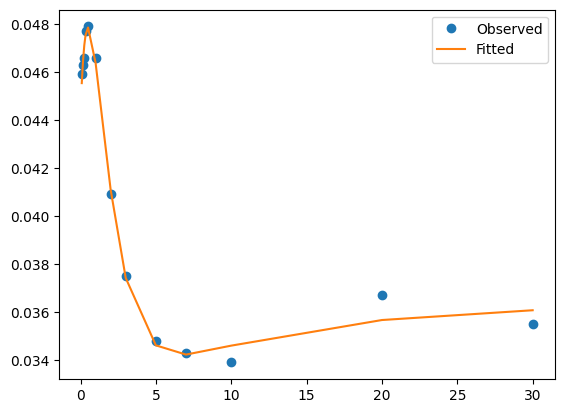

In [135]:
date0 = df_params["date"].iloc[0]
row_y = y_panel.loc[date0].values

params0 = df_params[df_params["date"] == date0].iloc[0]
tau_test = maturities
y_fit = (
    params0.beta0
    + params0.beta1 * g1(tau_test, params0.tau1)
    + params0.beta2 * g2(tau_test, params0.tau1)
    + params0.beta3 * g3(tau_test, params0.tau2)
)
plt.plot(maturities, row_y, "o", label="Observed")
plt.plot(maturities, y_fit, "-", label="Fitted")
plt.legend()
plt.show()

In [140]:
df_params["date"] = pd.to_datetime(df_params["date"])

df_including_params = df.merge(df_params, on="date", how="left")
print(df_including_params.columns)

tau = df_including_params["tau"].to_numpy()

df_including_params["yhat"] = (
    df_including_params["beta0"]
    + df_including_params["beta1"] * g1(tau, df_including_params["tau1"])
    + df_including_params["beta2"] * g2(tau, df_including_params["tau1"])
    + df_including_params["beta3"] * g3(tau, df_including_params["tau2"])
)
df_curve = (
    df_including_params[["date", "tau", "yhat"]]
    .drop_duplicates(subset=["date", "tau"])
    .sort_values(["date", "tau"])
    .reset_index(drop=True)
)
df["yhat"] = df_curve["yhat"]
print(df_curve[["date", "tau", "yhat"]].head)

Index(['optionid', 'date', 'exdate', 'dte', 'tau', 'strike_price', 'V_t',
       'impl_volatility', 'delta', 'V_t_plus_1', 'dV_t', 'dS_t', 'beta0',
       'beta1', 'beta2', 'beta3', 'tau1', 'tau2', 'sse'],
      dtype='str')
<bound method NDFrame.head of           date       tau      yhat
0   2023-02-01  0.005479  0.044388
1   2023-02-01  0.013699  0.044525
2   2023-02-01  0.016438  0.044569
3   2023-02-01  0.019178  0.044614
4   2023-02-01  0.021918  0.044657
..         ...       ...       ...
854 2023-02-27  1.315068  0.050228
855 2023-02-27  1.813699  0.048430
856 2023-02-27  2.810959  0.045224
857 2023-02-27  3.808219  0.043122
858 2023-02-27  4.805479  0.041843

[859 rows x 3 columns]>


In [141]:
def r_tau(tau, y_hat):
    return 2*np.log(1+y_hat/2)

def P_tau(tau, y_hat):
    return np.e**(-r_tau(tau, y_hat)*tau)

def F_tau(tau, y_hat, S, q=0):
    return S*np.e**(-(r_tau(tau, y_hat)-q)*tau)



In [149]:
df["delta_BS"] = df["delta"]
df["eps_BS"] = df["dV_t"] - df["delta_BS"] * df["dS_t"]
df_eps = df.dropna(subset=["eps_BS"]).copy()

eps = df_eps["eps_BS"]

print("=== Summary of baseline residual ε_t(Δ^BS) ===")
print("N:", len(eps))
print("Mean:", eps.mean())
print("Std:", eps.std())
print("RMSE:", np.sqrt(np.mean(eps**2)))
print("Min:", eps.min())
print("Max:", eps.max())
print("Percentiles (1,5,50,95,99):",
      np.percentile(eps, [1,5,50,95,99]))

=== Summary of baseline residual ε_t(Δ^BS) ===
N: 107613
Mean: -1.3142103508217469
Std: 39.89903402279541
RMSE: 39.920486866646435
Min: -214.1117391000002
Max: 139.77744000000013
Percentiles (1,5,50,95,99): [-103.9330065   -71.29622136   -0.15656755   67.61844502   98.79974812]


In [150]:
df_filtered = df_eps.copy()
df_filtered = df_filtered[df_filtered["delta_BS"] > 0.05]
df_filtered = df_filtered[df_filtered["delta_BS"] < 0.95]
df_filtered = df_filtered[df_filtered["dte"] > 14]

In [154]:
df_b = df_filtered.copy()

# 9 equal-width bins over (0.05, 0.95)
delta_edges = np.linspace(0.05, 0.95, 10)  # 10 edges -> 9 bins

df_b["delta_bucket"] = pd.cut(
    df_b["delta_BS"],
    bins=delta_edges,
    include_lowest=False,   # open at 0.05
    right=True              # (a, b]
)

df_b["delta_bucket_id"] = pd.cut(
    df_b["delta_BS"],
    bins=delta_edges,
    labels=range(1, 10),
    include_lowest=False,
    right=True
).astype(int)

dmin = df_b["dte"].min()
dmax = df_b["dte"].max()

mat_edges = np.linspace(dmin, dmax, 8)  # 8 edges -> 7 bins

df_b["mat_bucket"] = pd.cut(
    df_b["dte"],
    bins=mat_edges,
    include_lowest=True,
    right=True
)

df_b["mat_bucket_id"] = pd.cut(
    df_b["dte"],
    bins=mat_edges,
    labels=range(1, 8),
    include_lowest=True,
    right=True
).astype(int)
print(df_b.columns)
n_buckets_used = df_b.groupby(["delta_bucket_id", "mat_bucket_id"]).size().shape[0]
print("Buckets with data:", n_buckets_used, "out of 63")

Index(['optionid', 'date', 'exdate', 'dte', 'tau', 'strike_price', 'V_t',
       'impl_volatility', 'delta', 'V_t_plus_1', 'dV_t', 'dS_t', 'yhat',
       'delta_BS', 'eps_BS', 'delta_bucket', 'delta_bucket_id', 'mat_bucket',
       'mat_bucket_id'],
      dtype='str')
Buckets with data: 54 out of 63


In [155]:
if "eps_BS" not in df_filtered.columns:
    df_filtered["delta_BS"] = df_filtered["delta"]
    df_filtered["eps_BS"] = df_filtered["dV_t"] - df_filtered["delta_BS"] * df_filtered["dS_t"]

# Drop missing
df_final = df_filtered.dropna(subset=["eps_BS"]).copy()

SSE_total = np.sum(df_final["eps_BS"]**2)
MSE_total = np.mean(df_final["eps_BS"]**2)

print("=== Final filtered sample performance ===")
print("N:", len(df_final))
print("Total SSE(Δ^BS):", SSE_total)
print("Total MSE(Δ^BS):", MSE_total)

=== Final filtered sample performance ===
N: 69837
Total SSE(Δ^BS): 98021459.70893347
Total MSE(Δ^BS): 1403.5748916610603


In [156]:
if "delta_bucket_id" not in df_final.columns:
    delta_edges = np.linspace(0.05, 0.95, 10)
    df_final["delta_bucket_id"] = pd.cut(
        df_final["delta_BS"],
        bins=delta_edges,
        labels=False,
        include_lowest=False,
        right=True
    ) + 1  # -> 1..9

# Maturity buckets: 7 bins over filtered maturity range
if "mat_bucket_id" not in df_final.columns:
    dmin, dmax = df_final["dte"].min(), df_final["dte"].max()
    mat_edges = np.linspace(dmin, dmax, 8)
    df_final["mat_bucket_id"] = pd.cut(
        df_final["dte"],
        bins=mat_edges,
        labels=False,
        include_lowest=True,
        right=True
    ) + 1 


Buckets with data: 54 out of 63


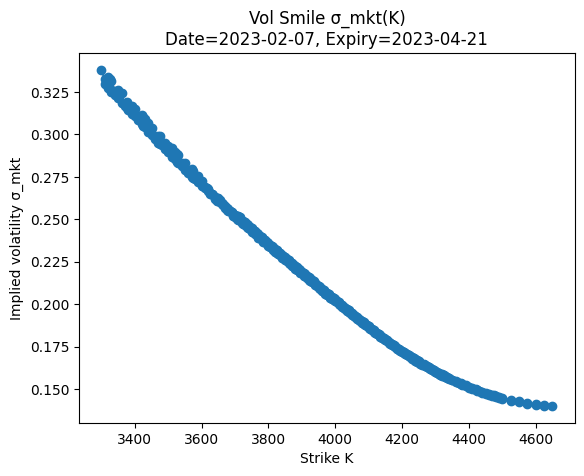

In [157]:
bucket = (
    df_final
    .groupby(["mat_bucket_id", "delta_bucket_id"])
    .agg(
        n=("eps_BS", "size"),
        SSE=("eps_BS", lambda x: float(np.sum(x**2))),
        MSE=("eps_BS", lambda x: float(np.mean(x**2)))
    )
    .reset_index()
)

# Make 7x9 tables (rows=maturity buckets, cols=delta buckets)
SSE_table = bucket.pivot(index="mat_bucket_id", columns="delta_bucket_id", values="SSE")
MSE_table = bucket.pivot(index="mat_bucket_id", columns="delta_bucket_id", values="MSE")

print("\nBuckets with data:", bucket.shape[0], "out of 63")

chosen_date = df_final["date"].mode().iloc[0]

tmp = df_final[df_final["date"] == chosen_date]
chosen_expiry = tmp["exdate"].value_counts().idxmax()

smile = df_final[(df_final["date"] == chosen_date) & (df_final["exdate"] == chosen_expiry)].copy()
smile = smile.sort_values("strike_price")

plt.figure()
plt.plot(smile["strike_price"], smile["impl_volatility"], marker="o", linestyle="-")
plt.xlabel("Strike K")
plt.ylabel("Implied volatility σ_mkt")
plt.title(f"Vol Smile σ_mkt(K)\nDate={chosen_date.date()}, Expiry={chosen_expiry.date()}")
plt.show()

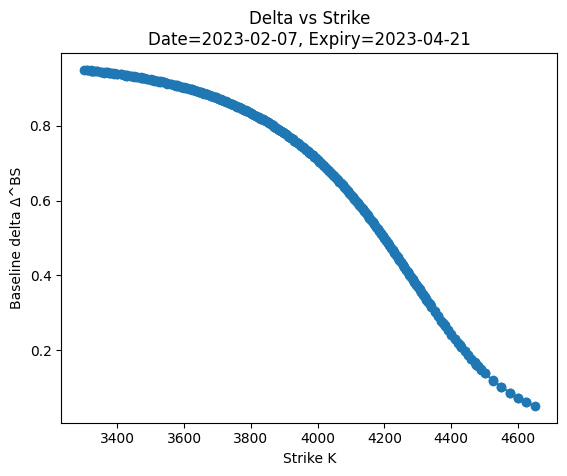

In [158]:
plt.figure()
plt.plot(smile["strike_price"], smile["delta_BS"], marker="o", linestyle="-")
plt.xlabel("Strike K")
plt.ylabel("Baseline delta Δ^BS")
plt.title(f"Delta vs Strike\nDate={chosen_date.date()}, Expiry={chosen_expiry.date()}")
plt.show()

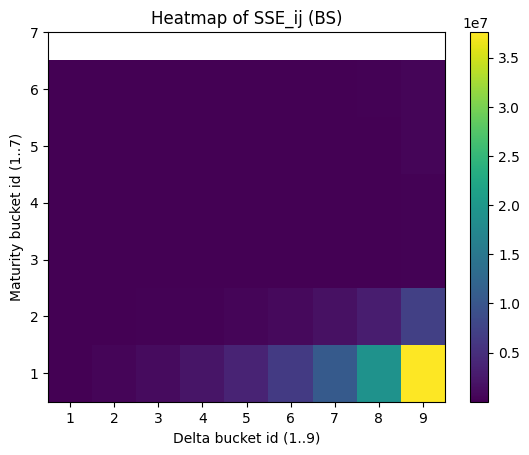

In [159]:
plt.figure()
plt.imshow(SSE_table.values, aspect="auto", origin="lower")
plt.colorbar()
plt.xlabel("Delta bucket id (1..9)")
plt.ylabel("Maturity bucket id (1..7)")
plt.title("Heatmap of SSE_ij (BS)")
plt.xticks(ticks=np.arange(9), labels=np.arange(1,10))
plt.yticks(ticks=np.arange(7), labels=np.arange(1,8))
plt.show()

In [ ]:
plt.figure()
plt.imshow(MSE_table.values, aspect="auto", origin="lower")
plt.colorbar()
plt.xlabel("Delta bucket id (1..9)")
plt.ylabel("Maturity bucket id (1..7)")
plt.title("Heatmap of MSE_ij (BS)")
plt.xticks(ticks=np.arange(9), labels=np.arange(1,10))
plt.yticks(ticks=np.arange(7), labels=np.arange(1,8))
plt.show()